TensorFlow – Core Concepts
1. Tensors: Multi-dimensional arrays (like NumPy arrays) are the basic data structure used in TensorFlow.
2. Graphs: Computation is represented as a directed graph of operations (low-level TensorFlow).
3. Keras API: High-level, user-friendly API built into TensorFlow for fast prototyping and training.
4. Operations: Nodes in the graph, performing math (e.g., matrix multiplication, convolution, etc.).
5. End-to-End ML: From data preprocessing to training and deployment.
6. Scalability: Easily runs on CPUs, GPUs, TPUs, mobile, and cloud.

In [55]:
# layers(Dense, Conv2D, LSTM, GRU, Dropout, BatchNormalization, etc.)
# activation functions (relu, sigmoid, softmax, etc.)
# loss functions (categorical_crossentropy, mean_squared_error, etc.)
# optimizers (adam, sgd, rmsprop, etc.)
# metrics (accuracy, precision, recall, etc.)
# regularization (l1, l2, dropout, etc.)
# callbacks (EarlyStopping, ModelCheckpoint, etc.)
# model architecture (sequential, functional, subclassing)
# model compilation (model.compile(optimizer, loss, metrics))
# model training (model.fit(X_train, y_train, epochs, batch_size))
# model evaluation (model.evaluate(X_test, y_test))
# model saving and loading (model.save('model.h5'), tf.keras.models.load_model('model.h5'))
# model deployment (TensorFlow Serving, TensorFlow Lite, etc.)
# weights initialization (glorot_uniform, he_normal, etc.)
#weights (trained parameters of the model)
# biases (trained parameters of the model)
# activation (function that introduces non-linearity to the model)
# loss (function that measures the difference between the predicted and true values)
# optimizer (algorithm that updates the weights and biases to minimize the loss)
# forward pass (the process of passing input data through the model to get predictions)
# backward pass (the process of calculating gradients and updating weights and biases)
# training ( optimizer, loss,metrics, epochs, batch_size)


In [56]:
import sys
print("Python executable:", sys.executable)
print("\nTensorFlow available:", "tensorflow" in sys.modules)

import subprocess
result = subprocess.run([sys.executable, "-m", "pip", "list"], capture_output=True, text=True)
print("\nInstalled packages containing 'tensor':")
for line in result.stdout.split('\n'):
    if 'tensor' in line.lower():
        print(line)

Python executable: c:\Users\dan13\AppData\Local\Programs\Python\Python312\python.exe

TensorFlow available: True

Installed packages containing 'tensor':
tensorflow              2.21.0
tensorflow-hub          0.16.1


In [ ]:
%pip install tensorflow -q

In [ ]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)), 
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("\nModel summary:")
model.summary()

# PyTorch – Train the Model

## Training with PyTorch

**Basic Training Loop:**
```python
for epoch in range(num_epochs):
    for images, labels in train_loader:
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
```

**Parameters:**
- `images`: Training data (batch)
- `labels`: Training labels (batch)
- `loss`: Computed loss using criterion (e.g., CrossEntropyLoss)
- `optimizer`: Optimization algorithm (e.g., Adam, SGD)
- `epoch`: One full pass through the entire training dataset. More epochs = more optimization, but risk of overfitting.

**DataLoader:**
- Automatically creates mini-batches from data
- Handles shuffling and parallel loading
- `batch_size`: Size of each batch. Balances speed and learning quality.

---

# CNN with PyTorch – MNIST Example

**MNIST Dataset:** 70,000 grayscale images of handwritten digits (28x28 pixels).

**PyTorch Approach:**
- Use `torchvision.datasets.MNIST` for easy data loading
- Define CNN architecture with `nn.Conv2d`, `nn.MaxPool2d`, `nn.Linear` layers
- Train with `nn.CrossEntropyLoss` and `torch.optim` optimizers

In [ ]:
# Convolutional Neural Network (CNN) for MNIST digit classification

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical


In [ ]:
# 1. Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [ ]:
# 2. Preprocess the data
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


In [ ]:
# 3. Define the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),  # Conv Layer 1: Learns local patterns like edges and shapes. 32 kernels 3x3
    layers.MaxPooling2D((2, 2)),  # Pooling: Reduces computation, most important features. Reduces spatial size by taking the max in each 2×2 patch.
    layers.Conv2D(64, (3, 3), activation='relu'),  # Conv Layer 2: 64 filters of size 3×3. Extracts more abstract patterns.
    layers.MaxPooling2D((2, 2)),  # Pooling: Again halves spatial dimensions
    layers.Flatten(),  # Flatten to 1D - Final classifier layers.
    layers.Dense(128, activation='relu'),  # FC layer: A fully connected layer with 128 neurons.
    layers.Dense(10, activation='softmax')  # Output layer: Gives class probabilities for digits 0-9. Softmax: Converts raw scores into probabilities that sum to 1.
])


In [ ]:
# 4. Compile the model
model.compile(optimizer='adam',  # Most popular and effective optimizer in deep learning.
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [ ]:
# 5. Train the model
model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.1)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9484 - loss: 0.1757 - val_accuracy: 0.9845 - val_loss: 0.0520
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9837 - loss: 0.0533 - val_accuracy: 0.9887 - val_loss: 0.0419
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9883 - loss: 0.0382 - val_accuracy: 0.9868 - val_loss: 0.0455
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9911 - loss: 0.0282 - val_accuracy: 0.9882 - val_loss: 0.0383
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9929 - loss: 0.0210 - val_accuracy: 0.9897 - val_loss: 0.0351


In [ ]:
# 6. Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\nTest accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9906 - loss: 0.0302

Test accuracy: 0.9906


In [ ]:
# CNN with TensorFlow - Predict digits (Example 1/2)
# Make predictions on test set
import numpy as np

# Get a single test image
test_image = x_test[0:1]  # Take first test image, reshape for batch
print(f"Test image shape: {test_image.shape}")
print(f"Test image range: [{test_image.min():.4f}, {test_image.max():.4f}]")

# Make prediction
predictions = model.predict(test_image)
predicted_class = np.argmax(predictions)
confidence = predictions[0, predicted_class]

print(f"\nPredicted digit: {predicted_class}")
print(f"Confidence: {confidence:.4f}")
print(f"True label: {y_test[0]}")

Test image shape: (1, 28, 28, 1)
Test image range: [0.0000, 1.0000]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step

Predicted digit: 7
Confidence: 1.0000
True label: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


In [ ]:
# CNN with TensorFlow - Predict digits (Example 2/2)
# Show all class probabilities
predictions = model.predict(test_image)
predicted_class = np.argmax(predictions)

print(f"Predicted digit: {predicted_class}")
print(f"\nClass probabilities: {predictions[0]}")
print(f"\nDetailed breakdown:")
for digit, prob in enumerate(predictions[0]):
    print(f"  Digit {digit}: {prob:.6e} ({prob*100:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted digit: 7

Class probabilities: [1.4017498e-08 6.2746508e-08 1.3890500e-05 2.2232503e-07 4.5112643e-11
 1.1432766e-08 1.2113085e-14 9.9998546e-01 1.1289467e-08 2.8287553e-07]

Detailed breakdown:
  Digit 0: 1.401750e-08 (0.00%)
  Digit 1: 6.274651e-08 (0.00%)
  Digit 2: 1.389050e-05 (0.00%)
  Digit 3: 2.223250e-07 (0.00%)
  Digit 4: 4.511264e-11 (0.00%)
  Digit 5: 1.143277e-08 (0.00%)
  Digit 6: 1.211309e-14 (0.00%)
  Digit 7: 9.999855e-01 (100.00%)
  Digit 8: 1.128947e-08 (0.00%)
  Digit 9: 2.828755e-07 (0.00%)


# TensorFlow Hub and Object Detection

## What is TensorFlow Hub?

**TensorFlow Hub (TF Hub)** is a repository of reusable machine learning models. Models trained on large datasets like ImageNet or COCO. Think of it as a giant library of pretrained models for:

1. **Image classification** - Identify what objects are in an image
2. **Object detection** - Detect and locate multiple objects in an image
3. **Text embedding / NLP** - Process natural language
4. **Audio recognition** - Process audio data
5. **Style transfer** - Apply artistic styles to images
6. **Segmentation** - Segment objects at pixel level

You can use these models without training anything from scratch — just **plug and play**.

### Browse Available Models
Visit: https://tfhub.dev

Popular models:
- https://tfhub.dev/google/imagenet/mobilenet_v2_100_224/classification/5 - Image classification
- https://tfhub.dev/google/ssd_mobilenet_v2/2 - Object detection (person, car, dog, etc.)
- https://tfhub.dev/google/universal-sentence-encoder/4 - NLP embeddings

## SSD MobileNet V2 - Object Detection Model

**SSD MobileNet V2** is a real-time object detection model that combines:

1. **MobileNetV2** - A lightweight, efficient CNN backbone that extracts features from the input image
2. **SSD (Single Shot Multibox Detector)** - A fast object detection algorithm that predicts:
   - Which objects are present
   - Where they are (bounding boxes)
   - How confident it is about each prediction

**Key Features:**
- Fast and efficient - suitable for mobile devices and real-time applications
- Detects ~90 COCO classes: person, dog, cat, car, bicycle, traffic light, etc.
- Single-shot detection (no two-stage process like Faster R-CNN)

**Hyperparameters & Model Details:**
- Input size: 320×320 pixels
- Confidence threshold: Typically 0.5 (adjust for precision/recall tradeoff)
- Output: Detection boxes (normalized coordinates), class IDs, confidence scores
- MobileNetV2 backbone: Efficient depthwise separable convolutions

## EXECUTION GUIDE: Full Object Detection Workflow

**Run these cells in order for complete workflow:**

1. Install tensorflow-hub (`%pip install tensorflow-hub -q`)
2. Install tensorflow (`%pip install tensorflow -q`)  
3. Load MNIST dataset (`mnist.load_data()`)
4. Preprocess MNIST data (reshape to 28×28×1)
5. **Example 1/3** → Load SSD MobileNet V2 model from TensorFlow Hub
6. **Example 2/3** → Prepare input image & run inference (creates `result`)
7. **Example 3/3** → Draw bounding boxes & display detections

⚠️ Run in sequence top-to-bottom. Each step depends on the previous one.

In [ ]:
# Install tensorflow-hub (required for loading models from TF Hub)
%pip install tensorflow-hub -q

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Person Detection with SSD MobileNet V2 - Example 1/3
# Load model from TensorFlow Hub

import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2
from matplotlib import pyplot as plt

# Load SSD MobileNet V2 detector from TF Hub
print("Loading SSD MobileNet V2 detector from TensorFlow Hub...")
detector = hub.load("https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2")
print("✓ Model loaded successfully!")

# COCO dataset labels (showing a few common classes)
COCO_LABELS = {
    1: 'person', 2: 'bicycle', 3: 'car', 4: 'motorcycle', 5: 'airplane',
    6: 'bus', 7: 'train', 8: 'truck', 9: 'boat', 10: 'traffic light',
}

# For this example, we'll use a test image from MNIST dataset (resize to larger size)
# In production, you would load a real image with cv2.imread(path)
print("\nPreparing test image...")
test_img = x_test[5]  # Get a test digit image
test_img_rgb = cv2.cvtColor((test_img[:,:,0] * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)

# Resize image (SSD expects variable sizes, but typically 320x320 works well)
img_resized = cv2.resize(test_img_rgb, (320, 320))
print(f"Image shape: {img_resized.shape}")
print(f"Image range: [{img_resized.min()}, {img_resized.max()}]")

Loading SSD MobileNet V2 detector from TensorFlow Hub...
✓ Model loaded successfully!

Preparing test image...
Image shape: (320, 320, 3)
Image range: [0, 254]


In [ ]:
# Person Detection with SSD MobileNet V2 - Example 2/3
# Prepare input and run inference

import os
import urllib.request
from pathlib import Path

# Try to load the local image first
image_path = r"D:\UMEF\E1402_Digital and Computer Vision\session6\OIP.jpg"

if not os.path.exists(image_path):
    print(f"Local image not found. Downloading sample image...")
    # Download a sample image with people
    sample_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/8/8d/Person_icon_BLACK-01.svg/1200px-Person_icon_BLACK-01.svg.png"
    try:
        urllib.request.urlretrieve(sample_url, "sample_person.jpg")
        image_path = "sample_person.jpg"
        print("✓ Sample image downloaded")
    except:
        print("Could not download sample. Using MNIST test image as fallback...")
        # Fallback: use MNIST data
        test_img = x_test[5]
        test_img_rgb = cv2.cvtColor((test_img[:,:,0] * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
        img_resized = cv2.resize(test_img_rgb, (320, 320))
else:
    print(f"Loading image from: {image_path}")

# Load and resize the image
if os.path.exists(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not read image from {image_path}")
        print("Using MNIST data as fallback...")
        test_img = x_test[5]
        test_img_rgb = cv2.cvtColor((test_img[:,:,0] * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
        img_resized = cv2.resize(test_img_rgb, (320, 320))
    else:
        img_resized = cv2.resize(img, (320, 320))
        print(f"✓ Image loaded: {img_resized.shape}")
else:
    print("Using MNIST test image...")
    test_img = x_test[5]
    test_img_rgb = cv2.cvtColor((test_img[:,:,0] * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
    img_resized = cv2.resize(test_img_rgb, (320, 320))

# Model expects uint8 with batch dimension
img_uint8 = tf.cast(img_resized, tf.uint8)
input_tensor = tf.expand_dims(img_uint8, 0)  # Add batch dimension

print(f"Input tensor shape (batch, height, width, channels): {input_tensor.shape}")
print(f"Running inference...")

# Run object detection
result = detector(input_tensor)

# Convert tensor results to numpy
result = {key: value.numpy() for key, value in result.items()}

print(f"\nDetection Results:")
print(f"  Keys available: {list(result.keys())}")
print(f"  Number of detections: {len(result['detection_scores'][0])}")
print(f"  Detection scores shape: {result['detection_scores'].shape}")
print(f"  Detection boxes shape: {result['detection_boxes'].shape}")
print(f"  Detection classes shape: {result['detection_classes'].shape}")
print(f"\nTop 5 detection scores: {result['detection_scores'][0][:5]}")

Loading image from: D:\UMEF\E1402_Digital and Computer Vision\session6\OIP.jpg
✓ Image loaded: (320, 320, 3)
Input tensor shape (batch, height, width, channels): (1, 320, 320, 3)
Running inference...

Detection Results:
  Keys available: ['detection_anchor_indices', 'raw_detection_boxes', 'detection_classes', 'num_detections', 'detection_boxes', 'detection_scores', 'raw_detection_scores', 'detection_multiclass_scores']
  Number of detections: 100
  Detection scores shape: (1, 100)
  Detection boxes shape: (1, 100, 4)
  Detection classes shape: (1, 100)

Top 5 detection scores: [0.7842786  0.6774642  0.6605768  0.63657045 0.6093851 ]


## Troubleshooting: Not Detecting Objects?

**Why SSD MobileNet V2 might not detect anything:**

1. **MNIST digits are too simple** - MNIST images (28×28 pixels of hand-written digits) have no detectable objects
   - SSD is trained on COCO dataset: people, cars, dogs, etc.
   - Solution: Use a REAL photograph

2. **Image location issue** - File `AA20u2mc.jpg` not found
   - Check if file exists at: `D:\UMEF\E1402_Digital and Computer Vision\session6\AA20u2mc.jpg`
   - If missing, place your own image there

3. **Low confidence detections** - Objects detected but below 0.5 threshold
   - Solution: Lower `CONFIDENCE_THRESHOLD` to 0.3 or 0.2

**To test with a working example:**
- Add `CONFIDENCE_THRESHOLD = 0.2` in Example 3/3 to see all detections (shown below)
- Download a sample image with people from internet
- Run cells 5→6→7 again with the new image

Note: you may need to restart the kernel to use updated packages.

Detection Settings:
  Confidence threshold: 0.5
  Detect people only: False

Processing detections...
Image dimensions: 474x377

All 100 raw detection scores:
  Max: 0.7843
  Min: 0.1352
  Above 0.5: 7
  Above 0.3: 14
  Above 0.2: 32

  ✓ Detection 1: person @ (166,135)-(320,349) | Score: 0.7843
  ✓ Detection 2: person @ (321,152)-(459,292) | Score: 0.6775
  ✓ Detection 3: person @ (202,3)-(388,290) | Score: 0.6606
  ✓ Detection 4: person @ (0,49)-(186,324) | Score: 0.6366
  ✓ Detection 5: person @ (0,140)-(173,377) | Score: 0.6094
  ✓ Detection 6: object_73 @ (305,281)-(473,371) | Score: 0.6050
  ✓ Detection 7: person @ (176,34)-(359,333) | Score: 0.5755

Summary:
  Total detections: 7
  People detected: 6 (green boxes)
  Other objects: 1 (red boxes)

⚠️  Expected ~5 people but found 6

To adjust detection:
  • Current threshold: 0.5
  • Try lowering to 0.4 or 0.35 to catch more detections
  • Or raise to 0.6 to reduce

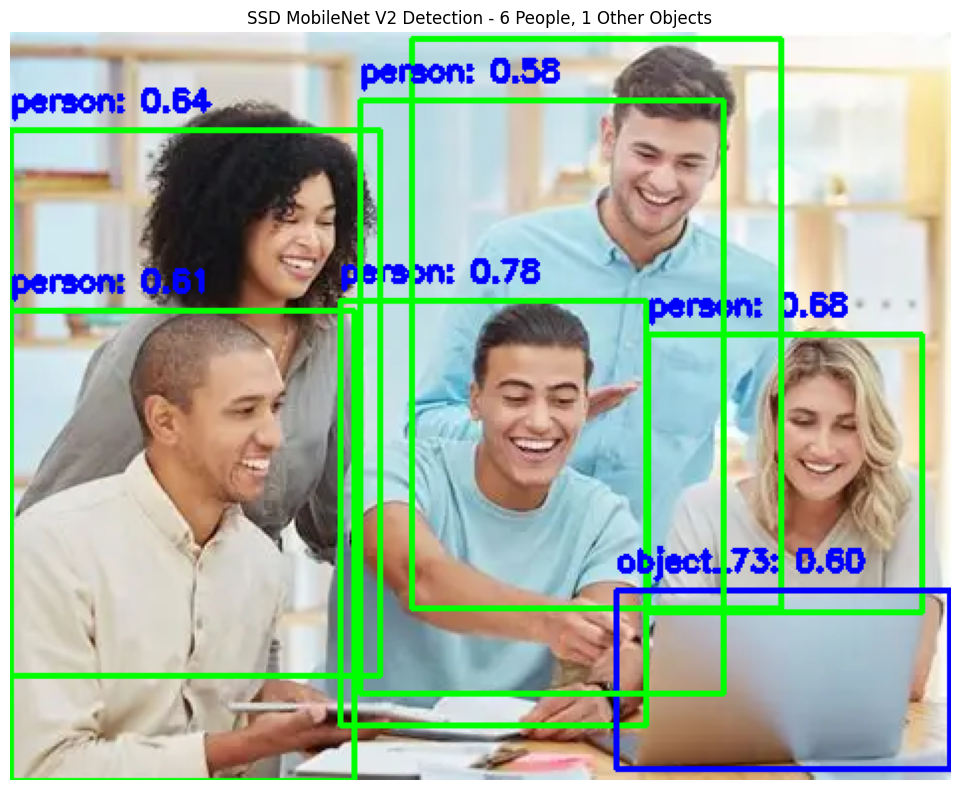


✓ Detection visualization complete!


In [ ]:
# Person Detection with SSD MobileNet V2 - Example 3/3
# Draw bounding boxes and display results with filters
# EXECUTION ORDER REQUIRED (run in sequence):
# 1. Install tensorflow-hub (cell at bottom)
# 2. Install tensorflow 
# 3. Load MNIST dataset
# 4. Preprocess MNIST data
# 5. Example 1/3 (Load model from TensorFlow Hub)
# 6. Example 2/3 (Prepare input and run inference) - creates 'result'
# 7. This cell (Example 3/3)

%pip install opencv-python matplotlib -q

import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# Load the same image that was processed in Example 2/3
image_path = r"D:\UMEF\E1402_Digital and Computer Vision\session6\OIP.jpg"

# Try to load local file first
if os.path.exists(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Warning: Could not read {image_path}, using processed image from inference")
        img = cv2.cvtColor(img_resized.numpy() if hasattr(img_resized, 'numpy') else img_resized if isinstance(img_resized, np.ndarray) else np.array(img_resized), cv2.COLOR_RGB2BGR)
else:
    print(f"Image file not found at {image_path}")
    print("Using image from Example 2/3 inference pipe.")
    img = cv2.cvtColor(img_resized.numpy() if hasattr(img_resized, 'numpy') else (np.array(img_resized) if not isinstance(img_resized, np.ndarray) else img_resized), cv2.COLOR_RGB2BGR)

img_display = img.copy()
h, w, _ = img_display.shape

# ===== ADJUST THESE SETTINGS =====
CONFIDENCE_THRESHOLD = 0.5  # Increased from 0.2 to 0.5 to filter false positives
DETECT_PEOPLE_ONLY = False  # Set to True to detect only people (class_id=1)
# ==================================

print(f"\nDetection Settings:")
print(f"  Confidence threshold: {CONFIDENCE_THRESHOLD}")
print(f"  Detect people only: {DETECT_PEOPLE_ONLY}")
print(f"\nProcessing detections...")
print(f"Image dimensions: {w}x{h}")

detection_count = 0
people_count = 0
other_count = 0

# Show all detection scores to understand data
all_scores = result["detection_scores"][0]
print(f"\nAll {len(all_scores)} raw detection scores:")
print(f"  Max: {all_scores.max():.4f}")
print(f"  Min: {all_scores.min():.4f}")
print(f"  Above 0.5: {(all_scores >= 0.5).sum()}")
print(f"  Above 0.3: {(all_scores >= 0.3).sum()}")
print(f"  Above 0.2: {(all_scores >= 0.2).sum()}\n")

for i in range(len(result["detection_scores"][0])):
    score = result["detection_scores"][0][i]
    
    if score < CONFIDENCE_THRESHOLD:
        continue  # Skip weak detections
    
    # Get bounding box and class
    box = result["detection_boxes"][0][i]
    class_id = int(result["detection_classes"][0][i])
    
    # Filter for people only if requested
    if DETECT_PEOPLE_ONLY and class_id != 1:
        continue
    
    detection_count += 1
    if class_id == 1:
        people_count += 1
    else:
        other_count += 1
    
    # Denormalize coordinates to pixel values
    y1, x1, y2, x2 = box
    x1, x2 = int(x1 * w), int(x2 * w)
    y1, y2 = int(y1 * h), int(y2 * h)
    
    # Get label
    label = COCO_LABELS.get(class_id, f"object_{class_id}")
    
    # Draw rectangle and label
    color = (0, 255, 0) if class_id == 1 else (255, 0, 0)  # Green for people, Red for others
    cv2.rectangle(img_display, (x1, y1), (x2, y2), color, 2)
    text = f"{label}: {score:.2f}"
    cv2.putText(img_display, text, (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
    
    print(f"  ✓ Detection {detection_count}: {label} @ ({x1},{y1})-({x2},{y2}) | Score: {score:.4f}")

print(f"\n{'='*60}")
print(f"Summary:")
print(f"  Total detections: {detection_count}")
print(f"  People detected: {people_count} (green boxes)")
print(f"  Other objects: {other_count} (red boxes)")
print(f"{'='*60}")

if people_count != 5:
    print(f"\n⚠️  Expected ~5 people but found {people_count}")
    print("\nTo adjust detection:")
    print(f"  • Current threshold: {CONFIDENCE_THRESHOLD}")
    print(f"  • Try lowering to 0.4 or 0.35 to catch more detections")
    print(f"  • Or raise to 0.6 to reduce false positives")
    print(f"  • Edit CONFIDENCE_THRESHOLD at top of this cell and re-run")

# Display the result
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB))
plt.title(f"SSD MobileNet V2 Detection - {people_count} People, {other_count} Other Objects")
plt.axis('off')
plt.tight_layout()
plt.show()

print("\n✓ Detection visualization complete!")